# CBA-MobileViT-S (lite) on ImageNet-100

**Model:** Convolutional Bottleneck Attention MobileViT-S — downsized CBA-block variant  
**Backbone:** MV2 blocks identical to MobileViT-S  
**Change:** 3x MobileViT transformer blocks replaced by 4x CBA blocks (one extra upstream after Stage 1)  
**Dataset:** ImageNet-100 (100 classes)  
**Resolution:** 256x256  
**Duration:** 50 epochs, cosine LR + linear warmup  

**Recipe:** RandAugment + Mixup/CutMix, model EMA, stochastic depth on CBA branches, decoupled weight decay. `drop_path_rate=0.05` and `ema_decay=0.995` are tuned down for the shorter schedule.

In [1]:
import os, math, time, csv, copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as T
from datasets import load_dataset
from tqdm.auto import tqdm

# inline so the results figure is embedded in the saved notebook
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'bf16 supported: {torch.cuda.is_bf16_supported()}')

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
bf16 supported: True


In [2]:
# mount Drive so checkpoints and logs survive across Colab sessions
# skip and set CFG['save_dir'] to a local path if running outside Colab
from google.colab import drive
drive.mount('/content/drive')

_drive_out = Path('/content/drive/MyDrive/colab')
_drive_out.mkdir(parents=True, exist_ok=True)
print(f'Output directory : {_drive_out}  (exists: {_drive_out.exists()})')

Mounted at /content/drive
Output directory : /content/drive/MyDrive/colab  (exists: True)


In [3]:
CFG = {
    # training
    'epochs'         : 50,
    'batch_size'     : 512,
    'num_workers'    : 8,
    'num_classes'    : 100,
    'img_size'       : 256,

    # optimizer
    # 1.5e-3 sits between sqrt-scaling (1.13e-3) and linear scaling (3.2e-3) from the B=64 reference
    'lr'             : 1.5e-3,
    'weight_decay'   : 0.05,
    'grad_clip'      : 1.0,

    # 10-epoch warmup pairs safely with the more aggressive LR
    'warmup_epochs'  : 10,

    # loss
    'label_smoothing': 0.1,

    # augmentation
    'randaug_n'      : 2,
    'randaug_m'      : 9,
    'mixup_alpha'    : 0.2,
    'cutmix_alpha'   : 1.0,
    'mixup_prob'     : 0.5,    # prob a batch is mixed at all
    'mixup_switch'   : 0.5,    # prob of CutMix vs Mixup when applied

    # regularization
    # drop_path halved for the 50-epoch run
    # ema_decay tightened because B=512 gives ~8x fewer steps/epoch than the B=64 reference
    'drop_path_rate' : 0.05,
    'ema_decay'      : 0.995,

    # bf16 on Ampere+ has fp32 dynamic range so no GradScaler needed
    # fall back to fp16 + GradScaler on Turing (T4)
    'amp'            : True,
    'amp_dtype'      : 'bf16',

    'seed'           : 42,

    # drive.mount cell above creates this path
    'save_dir'       : '/content/drive/MyDrive/colab',
    'run_name'       : 'cba_mobilevit_s_lite_in100',
}

torch.manual_seed(CFG['seed'])

In [4]:
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

# RandAugment replaces the older ColorJitter stack
# colour is a strong class cue in IN-100 so RandomGrayscale was actively harmful
train_tf = T.Compose([
    T.RandomResizedCrop(CFG['img_size'], scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=CFG['randaug_n'], magnitude=CFG['randaug_m']),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

val_tf = T.Compose([
    T.Resize(int(CFG['img_size'] / 0.875)),   # 0.875 crop ratio matches MobileViT-S eval
    T.CenterCrop(CFG['img_size']),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])


class HFImageDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.ds = hf_split
        self.tf = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        return self.tf(item['image'].convert('RGB')), item['label']


print('Loading ImageNet-100 from HuggingFace...')
hf_dataset = load_dataset('clane9/imagenet-100')
print(f"Train size : {len(hf_dataset['train'])}")
print(f"Val size   : {len(hf_dataset['validation'])}")

train_ds = HFImageDataset(hf_dataset['train'],      train_tf)
val_ds   = HFImageDataset(hf_dataset['validation'], val_tf)

_pw = CFG['num_workers'] > 0
# drop_last keeps step count identical to the baseline notebook
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'],
                          drop_last=True,
                          pin_memory=True, persistent_workers=_pw,
                          prefetch_factor=4 if _pw else None)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'] * 2,
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=True, persistent_workers=_pw,
                          prefetch_factor=4 if _pw else None)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

Loading ImageNet-100 from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

data/train-00000-of-00017.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Train size : 126689
Val size   : 5000
Train batches: 247
Val batches  : 5


## Model Definition

Five classes wire together to form `CBAMobileViT`:

| Class | Role |
|---|---|
| `MV2Block` | MobileNetV2 inverted residual block — backbone unchanged from MobileViT-S |
| `DSCEncoderStage` / `DSCDecoderStage` | MV2-style depthwise-separable stages inside the CBA block |
| `TransformerBlock` | MHSA + FFN block on the compressed bottleneck latent |
| `DropPath` | Per-sample stochastic depth (Huang et al. 2016) |
| `CBABlock` | Encoder → attention → decoder → Hadamard gate |
| `CBAMobileViT` | Full network: stem → 5 MV2 stages interleaved with 4 CBA blocks → head |

In [5]:
# MobileNetV2 inverted residual block, unchanged from MobileViT-S
# skip connection when stride==1 and channels match; expand_ratio=1 skips the expand conv
class MV2Block(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        self.use_skip = (stride == 1 and in_ch == out_ch)
        mid_ch = int(in_ch * expand_ratio)
        layers = []
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_ch, mid_ch, 1, bias=False),
                nn.BatchNorm2d(mid_ch),
                nn.SiLU(inplace=True),
            ]
        layers += [
            nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        ]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        return x + out if self.use_skip else out

### DSC Stages — MV2 inverted-residual pattern

Each `DSC*Stage` follows the MobileNetV2 inverted-residual pattern (Sandler et al., MobileNetV2 §3, CVPR 2018):

```
PW(C_in -> t*C_in) -> BN -> SiLU          [expand to t*C_in]
DW_3x3(s, groups=t*C_in) -> BN -> SiLU    [spatial filter at expanded width]
PW(t*C_in -> C_out) -> BN                 [LINEAR project, no activation]
```

The linear project at the narrow endpoint is non-negotiable — adding any non-linearity there destroys information at low dimension, costing 1-2pp on ImageNet (Sandler Table 6). This rule is uniform across E1, E2, D1, D2.

The decoder mirror inserts bilinear upsampling between expand and DW so the spatial filter runs at the upsampled resolution. D2's `project_bn.bias` is initialised to -3 so the gate starts near identity (sigmoid(-3) ≈ 0.05).

In [6]:
# MV2-style encoder: PW expand -> DW spatial -> PW linear project
class DSCEncoderStage(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        mid = in_ch * expand_ratio

        self.expand_pw  = nn.Conv2d(in_ch, mid, 1, bias=False)
        self.expand_bn  = nn.BatchNorm2d(mid)
        self.expand_act = nn.SiLU(inplace=True)

        self.dw     = nn.Conv2d(mid, mid, 3, stride=stride, padding=1,
                                groups=mid, bias=False)
        self.dw_bn  = nn.BatchNorm2d(mid)
        self.dw_act = nn.SiLU(inplace=True)

        # no activation at narrow endpoint (Sandler §3 linear bottleneck rule)
        self.project_pw = nn.Conv2d(mid, out_ch, 1, bias=False)
        self.project_bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = self.expand_act(self.expand_bn(self.expand_pw(x)))
        x = self.dw_act(self.dw_bn(self.dw(x)))
        x = self.project_bn(self.project_pw(x))
        return x


# MV2-style decoder: same pattern with bilinear upsample inserted before DW
class DSCDecoderStage(nn.Module):
    def __init__(self, in_ch, out_ch, scale_factor=1, expand_ratio=4):
        super().__init__()
        mid = in_ch * expand_ratio
        self.scale = scale_factor

        self.expand_pw  = nn.Conv2d(in_ch, mid, 1, bias=False)
        self.expand_bn  = nn.BatchNorm2d(mid)
        self.expand_act = nn.SiLU(inplace=True)

        self.dw     = nn.Conv2d(mid, mid, 3, padding=1, groups=mid, bias=False)
        self.dw_bn  = nn.BatchNorm2d(mid)
        self.dw_act = nn.SiLU(inplace=True)

        # no activation at narrow endpoint
        self.project_pw = nn.Conv2d(mid, out_ch, 1, bias=False)
        self.project_bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = self.expand_act(self.expand_bn(self.expand_pw(x)))
        if self.scale > 1:
            x = F.interpolate(x, scale_factor=self.scale,
                              mode='bilinear', align_corners=False)
        x = self.dw_act(self.dw_bn(self.dw(x)))
        x = self.project_bn(self.project_pw(x))
        return x

In [7]:
# pre-norm MHSA + FFN block
# FFN is kept to prevent rank collapse and preserve per-position channel mixing capacity
class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads, ffn_mult=2, attn_drop=0.0, ffn_drop=0.0):
        super().__init__()
        assert dim % n_heads == 0, f'dim {dim} must be divisible by n_heads {n_heads}'
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, n_heads, dropout=attn_drop,
                                            batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        ffn_dim    = int(dim * ffn_mult)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, ffn_dim),
            nn.SiLU(),
            nn.Linear(ffn_dim, dim),
        )
        self.drop  = nn.Dropout(ffn_drop)

    def forward(self, x):
        # x: (B, N, C)
        xn = self.norm1(x)
        h, _ = self.attn(xn, xn, xn, need_weights=False)
        x = x + self.drop(h)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

### CBA Block — Convolutional Bottleneck Attention

```
Encoder (2 DSC stages)  →  n_layers × (MHSA + FFN) on compact latent
                         →  Decoder (2 DSC stages)  →  Hadamard gate
```

**Output:**

`Y = X + DropPath(sigmoid(decode(attn(encode(X)))) ⊙ X) ≈ (1 + α) ⊙ X`

with α ∈ (0, 1) at eval.

**Gradient safety:** the `+X` arm preserves the "+1" gradient highway (He et al., ECCV 2016 Eq. 5). The multiplier `(1+α) ∈ (1, 2)` amplifies signal — never cancels it.

**Initialisation:** `D2.project_bn.bias = −3` → sigmoid(−3) ≈ 0.047 → block starts as a ~5% identity contribution and opens gradually (ReZero-style warm-up).

The DW filter inside each DSC stage sees `t×` more channel evidence per spatial position; `expand_ratio=4` matches MobileViT-S's MV2 stages, `expand_ratio=2` matches MobileViTv2's IRBs.

**Args:**

| Arg | Meaning |
|---|---|
| `c_in` | input/output channels — block is shape-preserving |
| `c_mid` | intermediate channels between E1/E2 and D1/D2 |
| `c_prime` | bottleneck channels — MHSA operates here |
| `n_heads` | number of attention heads (`c_prime` must be divisible by `n_heads`) |
| `stride1`, `stride2` | spatial strides for E1/E2; D2/D1 upsample by the same factors |
| `n_layers` | number of stacked transformer layers |
| `ffn_mult` | FFN hidden multiplier (default 2 → hidden = 2·`c_prime`) |
| `drop_path_rate` | per-block stochastic-depth drop probability |
| `expand_ratio` | MV2 expansion ratio inside each DSC stage (default 4) |

In [8]:
# per-sample stochastic depth (Huang et al. 2016)
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep)
        return x.div(keep) * mask


# CBA block: encode -> attend -> decode -> Hadamard gate
# output: Y = X + DropPath(sigmoid(z) * X)  where z comes from the decoder
# D2.project_bn.bias=-3 so sigmoid(-3)~0.047 at init, block starts near identity
class CBABlock(nn.Module):
    def __init__(self, c_in, c_mid, c_prime, n_heads,
                 stride1=1, stride2=1, n_layers=1, ffn_mult=2,
                 drop_path_rate=0.0, expand_ratio=4):
        super().__init__()

        self.enc1 = DSCEncoderStage(c_in,  c_mid,   stride=stride1, expand_ratio=expand_ratio)
        self.enc2 = DSCEncoderStage(c_mid, c_prime, stride=stride2, expand_ratio=expand_ratio)

        self.tf = nn.Sequential(*[
            TransformerBlock(c_prime, n_heads, ffn_mult=ffn_mult)
            for _ in range(n_layers)
        ])

        self.dec1 = DSCDecoderStage(c_prime, c_mid, scale_factor=stride2, expand_ratio=expand_ratio)
        self.dec2 = DSCDecoderStage(c_mid,   c_in,  scale_factor=stride1, expand_ratio=expand_ratio)

        # warm-start near identity
        nn.init.constant_(self.dec2.project_bn.bias, -3.0)

        self.drop_path = DropPath(drop_path_rate)

    def forward(self, x):
        B, C, H, W = x.shape

        z = self.enc1(x)
        z = self.enc2(z)
        hp, wp = z.shape[2], z.shape[3]

        z = z.flatten(2).transpose(1, 2)      # B, h'*w', c_prime
        z = self.tf(z)
        z = z.transpose(1, 2).reshape(B, -1, hp, wp)

        z = self.dec1(z)
        z = self.dec2(z)

        alpha = torch.sigmoid(z)
        return x + self.drop_path(alpha * x)

### CBAMobileViT — Full Architecture

**Lite variant:** ~2.8M params, ~1.1G MACs, 256×256 input.

MV2 backbone byte-for-byte identical to MobileViT-S. CBA blocks downsized along three independent axes vs the original full variant:

1. **Reduced `c_prime`** (~17–25% across blocks). CBA-4 dropped 192 → 128 to make it a *real* bottleneck — the previous design produced a latent BIGGER than the input (10,240 → 12,288 elements), which is the opposite of compression. Now CBA-4 latent has 8,192 elements (1.25× ↓).
2. **Shallower transformer stacks** at the deepest blocks (CBA-3: 4 → 3, CBA-4: 3 → 2).
3. **Hybrid MV2 expansion ratio** `t` in the DSC encoder/decoder:
   - `t=4` retained at CBA-1 (high spatial extent benefits most from richer DW filtering at the expanded mid-width — Sandler MV2 §3).
   - `t=2` at CBA-2 / CBA-3 / CBA-4 (low spatial → marginal value of richer DW is small; halves encoder/decoder FLOPs and params; matches MobileViTv2's IRBs).

**CBA block specs** (256×256 input):

| Block | Input | Cmid | C′ | Bottleneck | n_heads | n_layers | strides | exp |
|---|---|---|---|---|---|---|---|---|
| CBA-1 | 32×128×128 | 48 | 72 | 72×16×16 | 3 | 2 | 4,2 | 4 |
| CBA-2 | 96×32×32 | 112 | 128 | 128×8×8 | 4 | 2 | 2,2 | 2 |
| CBA-3 | 128×16×16 | 144 | 160 | 160×8×8 | 4 | 3 | 2,1 | 2 |
| CBA-4 | 160×8×8 | 144 | 128 | 128×8×8 | 4 | 2 | 1,1 | 2 |

**Bottleneck compression ratios** (input H·W·C → latent h′·w′·c′):

| Block | Input → Latent | Ratio |
|---|---|---|
| CBA-1 | 524,288 → 18,432 | 28.4× ↓ (most aggressive — high-resolution input) |
| CBA-2 | 98,304 → 8,192 | 12.0× ↓ |
| CBA-3 | 32,768 → 10,240 | 3.2× ↓ |
| CBA-4 | 10,240 → 8,192 | 1.25× ↓ (least aggressive but still a real bottleneck; was 1.20× *expansion* before fix) |

The trajectory `28.4 → 12.0 → 3.2 → 1.25` is monotonically decreasing — consistent with the Information Bottleneck intuition: compress hard upstream where redundancy is highest, lighter downstream where features are already condensed.

Stochastic depth: linear schedule from 0 (CBA-1) to `drop_path_rate` (CBA-4) on each block's gated residual branch. Trained at 256×256 to match MobileViT-S/V2's canonical pretrained resolution; baselines are retrained at 256 for parity.

In [9]:
# CBA-MobileViT-S lite variant for ImageNet-100
# MV2 backbone unchanged from MobileViT-S; only the 4 CBA blocks differ
class CBAMobileViT(nn.Module):
    def __init__(self, num_classes=100, drop_path_rate=0.0):
        super().__init__()

        # linear DropPath schedule across the 4 CBA blocks
        dpr = [float(x) for x in torch.linspace(0.0, drop_path_rate, 4)]

        # stem: 256->128, 3->16
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU(inplace=True),
        )

        # stage 1: MV2 (16->32, t=1, s=1)  ->  128x128x32
        self.s1     = MV2Block(16, 32, stride=1, expand_ratio=1)

        # CBA-1: 16x16x72 bottleneck, 2 layers, t=4
        self.cba1   = CBABlock(c_in=32,  c_mid=48,  c_prime=72,  n_heads=3,
                               stride1=4, stride2=2, n_layers=2, ffn_mult=2,
                               drop_path_rate=dpr[0], expand_ratio=4)

        # stage 2: MV2 x3 (32->64, t=4, first s=2)  ->  64x64x64
        self.s2     = nn.Sequential(
            MV2Block(32, 64, stride=2, expand_ratio=4),
            MV2Block(64, 64, stride=1, expand_ratio=4),
            MV2Block(64, 64, stride=1, expand_ratio=4),
        )

        # stage 3: MV2 (64->96, t=4, s=2)  ->  32x32x96
        self.s3_mv2 = MV2Block(64, 96, stride=2, expand_ratio=4)
        self.cba2   = CBABlock(c_in=96,  c_mid=112, c_prime=128, n_heads=4,
                               stride1=2, stride2=2, n_layers=2, ffn_mult=2,
                               drop_path_rate=dpr[1], expand_ratio=2)

        # stage 4: MV2 (96->128, t=4, s=2)  ->  16x16x128
        self.s4_mv2 = MV2Block(96, 128, stride=2, expand_ratio=4)
        self.cba3   = CBABlock(c_in=128, c_mid=144, c_prime=160, n_heads=4,
                               stride1=2, stride2=1, n_layers=3, ffn_mult=2,
                               drop_path_rate=dpr[2], expand_ratio=2)

        # stage 5: MV2 (128->160, t=4, s=2)  ->  8x8x160
        self.s5_mv2 = MV2Block(128, 160, stride=2, expand_ratio=4)
        self.cba4   = CBABlock(c_in=160, c_mid=144, c_prime=128, n_heads=4,
                               stride1=1, stride2=1, n_layers=2, ffn_mult=2,
                               drop_path_rate=dpr[3], expand_ratio=2)

        # head: 160->640->100
        self.head   = nn.Sequential(
            nn.Conv2d(160, 640, 1, bias=False),
            nn.BatchNorm2d(640),
            nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc     = nn.Linear(640, num_classes)

    def forward(self, x):
        x = self.stem(x)          # B,  16, 128, 128
        x = self.s1(x)            # B,  32, 128, 128
        x = self.cba1(x)          # B,  32, 128, 128
        x = self.s2(x)            # B,  64,  64,  64
        x = self.s3_mv2(x)        # B,  96,  32,  32
        x = self.cba2(x)          # B,  96,  32,  32
        x = self.s4_mv2(x)        # B, 128,  16,  16
        x = self.cba3(x)          # B, 128,  16,  16
        x = self.s5_mv2(x)        # B, 160,   8,   8
        x = self.cba4(x)          # B, 160,   8,   8
        x = self.head(x).flatten(1)
        return self.fc(x)

In [10]:
# param count and forward-pass shape check
_model_check = CBAMobileViT(num_classes=CFG['num_classes'],
                            drop_path_rate=CFG['drop_path_rate'])

total_params     = sum(p.numel() for p in _model_check.parameters())
trainable_params = sum(p.numel() for p in _model_check.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:>10,}')
print(f'Trainable parameters: {trainable_params:>10,}')
print()

_comps = {
    'stem':         _model_check.stem,
    'stage1 MV2':   _model_check.s1,
    'CBA-1':        _model_check.cba1,
    'stage2 MV2x3': _model_check.s2,
    'stage3 MV2':   _model_check.s3_mv2,
    'CBA-2':        _model_check.cba2,
    'stage4 MV2':   _model_check.s4_mv2,
    'CBA-3':        _model_check.cba3,
    'stage5 MV2':   _model_check.s5_mv2,
    'CBA-4':        _model_check.cba4,
    'head conv+pool':_model_check.head,
    'fc':           _model_check.fc,
}
print(f'{"Component":<18} {"Params":>10}')
print('-' * 30)
for name, mod in _comps.items():
    n = sum(p.numel() for p in mod.parameters())
    print(f'{name:<18} {n:>10,}')

_model_check.eval()
with torch.no_grad():
    _dummy = torch.zeros(2, 3, CFG['img_size'], CFG['img_size'])
    _out   = _model_check(_dummy)
print()
print(f'Forward pass: {tuple(_dummy.shape)} -> {tuple(_out.shape)}')
assert _out.shape == (2, CFG['num_classes']), \
    f'Expected (2, {CFG["num_classes"]}), got {_out.shape}'
print('Shape check passed')
del _model_check, _dummy, _out

Total parameters:      2,785,956
Trainable parameters:  2,785,956

Component              Params
------------------------------
stem                      464
stage1 MV2                752
CBA-1                 178,528
stage2 MV2x3           86,528
stage3 MV2             44,480
CBA-2                 479,232
stage4 MV2             91,264
CBA-3                 968,608
stage5 MV2            154,432
CBA-4                 613,888
head conv+pool        103,680
fc                     64,100

Forward pass: (2, 3, 256, 256) → (2, 100)
Shape check passed ✓


## Training

In [11]:
# applies Mixup or CutMix per batch (50/50 given switch_prob, with overall prob `prob`)
# returns (imgs, label_a, label_b, lambda) for the mixed CE loss
class MixupCutmix:
    def __init__(self, mixup_alpha=0.2, cutmix_alpha=1.0,
                 prob=0.5, switch_prob=0.5):
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.prob = prob
        self.switch_prob = switch_prob

    def __call__(self, imgs, labels):
        if torch.rand(1).item() >= self.prob:
            return imgs, labels, labels, 1.0
        idx = torch.randperm(imgs.size(0), device=imgs.device)
        if torch.rand(1).item() < self.switch_prob:
            # CutMix
            lam = float(np.random.beta(self.cutmix_alpha, self.cutmix_alpha))
            H, W = imgs.shape[2], imgs.shape[3]
            cut_rat = math.sqrt(1.0 - lam)
            cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
            cx, cy = np.random.randint(W), np.random.randint(H)
            x1, y1 = max(0, cx - cut_w // 2), max(0, cy - cut_h // 2)
            x2, y2 = min(W, cx + cut_w // 2), min(H, cy + cut_h // 2)
            imgs[:, :, y1:y2, x1:x2] = imgs[idx, :, y1:y2, x1:x2]
            lam = 1.0 - ((x2 - x1) * (y2 - y1) / float(W * H))
        else:
            # Mixup
            lam = float(np.random.beta(self.mixup_alpha, self.mixup_alpha))
            imgs = lam * imgs + (1.0 - lam) * imgs[idx]
        return imgs, labels, labels[idx], lam


# exponential moving average of model weights; BN buffers are copied not averaged
class ModelEMA:
    def __init__(self, model, decay=0.9995):
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        d = self.decay
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1.0 - d)
            else:
                v.copy_(msd[k])


# weight decay on conv/linear weights only, skips BN, LN and biases
# standard ViT recipe, worth ~0.5-1pp over decaying everything
def build_param_groups(model, weight_decay):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith('.bias'):
            no_decay.append(p)
        else:
            decay.append(p)
    return [
        {'params': decay,    'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ]


def _amp_dtype(cfg):
    return torch.bfloat16 if cfg.get('amp_dtype', 'bf16') == 'bf16' else torch.float16


# one training epoch with Mixup/CutMix and EMA update
# train accuracy is against the original labels so it slightly under-reports under heavy mixing
def train_epoch(model, loader, criterion, optimizer, scaler, mixup, ema, epoch):
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    use_bf16 = CFG.get('amp_dtype', 'bf16') == 'bf16'
    dtype = _amp_dtype(CFG)

    for imgs, labels in tqdm(loader, desc=f'Train {epoch+1:>3}', leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        imgs, y_a, y_b, lam = mixup(imgs, labels)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', dtype=dtype, enabled=CFG['amp']):
            logits = model(imgs)
            loss   = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)

        if use_bf16:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            optimizer.step()
        else:
            # fp16 path needs GradScaler for dynamic loss scaling
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()

        if ema is not None:
            ema.update(model)

        bs        = imgs.size(0)
        tot_loss += loss.item() * bs
        correct  += (logits.detach().argmax(1) == y_a).sum().item()
        total    += bs

    return tot_loss / total, 100.0 * correct / total, time.time() - t0


@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    tot_loss, c1, c5, total = 0.0, 0, 0, 0
    dtype = _amp_dtype(CFG)

    for imgs, labels in tqdm(loader, desc='  Val    ', leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast('cuda', dtype=dtype, enabled=CFG['amp']):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        bs        = imgs.size(0)
        tot_loss += loss.item() * bs
        total    += bs
        c1       += (logits.argmax(1) == labels).sum().item()
        _, top5   = logits.topk(min(5, logits.size(1)), dim=1)
        c5       += (top5 == labels.unsqueeze(1)).any(1).sum().item()

    return tot_loss / total, 100.0 * c1 / total, 100.0 * c5 / total

In [12]:
import gc

# clean up any leftover GPU allocations from a previous run of this cell
for _name in ('model', 'ema', 'optimizer', 'scheduler', 'scaler', 'criterion', 'mixup'):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    _alloc = torch.cuda.memory_allocated() / 1e9
    _resvd = torch.cuda.memory_reserved()  / 1e9
    print(f'GPU after cleanup: {_alloc:.2f} GB allocated, {_resvd:.2f} GB reserved')

if CFG.get('amp_dtype', 'bf16') == 'bf16' and torch.cuda.is_available() \
        and not torch.cuda.is_bf16_supported():
    print("WARNING: bf16 requested but not supported on this GPU, falling back to fp16")
    CFG['amp_dtype'] = 'fp16'

Path(CFG['save_dir']).mkdir(parents=True, exist_ok=True)
log_path  = Path(CFG['save_dir']) / f"{CFG['run_name']}_log.csv"
ckpt_best = Path(CFG['save_dir']) / f"{CFG['run_name']}_best.pt"

model = CBAMobileViT(num_classes=CFG['num_classes'],
                     drop_path_rate=CFG['drop_path_rate']).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
optimizer = torch.optim.AdamW(
    build_param_groups(model, CFG['weight_decay']),
    lr=CFG['lr'], betas=(0.9, 0.999),
)

mixup = MixupCutmix(
    mixup_alpha=CFG['mixup_alpha'],
    cutmix_alpha=CFG['cutmix_alpha'],
    prob=CFG['mixup_prob'],
    switch_prob=CFG['mixup_switch'],
)

ema = ModelEMA(model, decay=CFG['ema_decay'])

def _lr_lambda(ep):
    # linear warmup then cosine decay
    if ep < CFG['warmup_epochs']:
        return (ep + 1) / CFG['warmup_epochs']
    t = (ep - CFG['warmup_epochs']) / max(1, CFG['epochs'] - CFG['warmup_epochs'])
    return 0.5 * (1.0 + math.cos(math.pi * t))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

# GradScaler only needed on the fp16 path; bf16 doesn't need loss scaling
if CFG.get('amp_dtype', 'bf16') == 'fp16':
    scaler = GradScaler('cuda', enabled=CFG['amp'])
else:
    scaler = None

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'epoch', 'train_loss', 'train_acc1',
        'val_loss',     'val_acc1',     'val_acc5',
        'ema_val_loss', 'ema_val_acc1', 'ema_val_acc5',
        'lr', 'time_s',
    ])

n_decay   = sum(p.numel() for p in optimizer.param_groups[0]['params'])
n_nodecay = sum(p.numel() for p in optimizer.param_groups[1]['params'])
print(f'Model  : CBAMobileViT  ({sum(p.numel() for p in model.parameters()):,} params)')
print(f'Optim  : AdamW  lr={CFG["lr"]}  wd={CFG["weight_decay"]} '
      f'(decay={n_decay:,}, no-decay={n_nodecay:,})')
print(f'Sched  : Cosine  warmup={CFG["warmup_epochs"]} epochs')
print(f'Aug    : RandAugment(N={CFG["randaug_n"]}, M={CFG["randaug_m"]}) '
      f'+ Mixup({CFG["mixup_alpha"]})/CutMix({CFG["cutmix_alpha"]}) p={CFG["mixup_prob"]}')
print(f'Reg    : drop_path={CFG["drop_path_rate"]}, EMA decay={CFG["ema_decay"]}')
print(f'Epochs : {CFG["epochs"]}')
print(f'AMP    : {CFG["amp"]}  ({CFG.get("amp_dtype", "bf16")})')
print(f'Device : {DEVICE}')
print(f'Log    : {log_path}')

GPU after cleanup: 0.00 GB allocated, 0.00 GB reserved
Model  : CBAMobileViT  (2,785,956 params)
Optim  : AdamW  lr=0.0015  wd=0.05 (decay=2,744,032, no-decay=41,924)
Sched  : Cosine  warmup=10 epochs
Aug    : RandAugment(N=2, M=9) + Mixup(0.2)/CutMix(1.0) p=0.5
Reg    : drop_path=0.05, EMA decay=0.995
Epochs : 50
AMP    : True  (bf16)
Device : cuda
Log    : /content/drive/MyDrive/colab/cba_mobilevit_s_lite_in100_log.csv


In [13]:
history   = {k: [] for k in ('train_loss', 'train_acc1',
                              'val_loss',     'val_acc1',     'val_acc5',
                              'ema_val_loss', 'ema_val_acc1', 'ema_val_acc5')}
best_acc1 = 0.0   # best of {live, EMA} top-1 ever seen

for epoch in range(CFG['epochs']):
    tr_loss, tr_acc1, tr_t        = train_epoch(
        model, train_loader, criterion, optimizer, scaler, mixup, ema, epoch)
    v_loss,  v_acc1,  v_acc5      = val_epoch(model,      val_loader, criterion)
    ev_loss, ev_acc1, ev_acc5     = val_epoch(ema.module, val_loader, criterion)
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]

    # Save best checkpoint when either live or EMA improves.
    epoch_best = max(v_acc1, ev_acc1)
    if epoch_best > best_acc1:
        best_acc1 = epoch_best
        torch.save({
            'epoch':           epoch + 1,
            'state_dict':      model.state_dict(),
            'ema_state_dict':  ema.module.state_dict(),
            'val_acc1':        v_acc1,  'val_acc5':  v_acc5,
            'ema_val_acc1':    ev_acc1, 'ema_val_acc5': ev_acc5,
            'cfg':             CFG,
        }, ckpt_best)

    # Append to CSV
    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch + 1, f'{tr_loss:.4f}', f'{tr_acc1:.2f}',
            f'{v_loss:.4f}',  f'{v_acc1:.2f}',  f'{v_acc5:.2f}',
            f'{ev_loss:.4f}', f'{ev_acc1:.2f}', f'{ev_acc5:.2f}',
            f'{current_lr:.6f}', f'{tr_t:.1f}',
        ])

    for k, v in [('train_loss',     tr_loss), ('train_acc1',   tr_acc1),
                 ('val_loss',       v_loss),  ('val_acc1',     v_acc1),  ('val_acc5',     v_acc5),
                 ('ema_val_loss',   ev_loss), ('ema_val_acc1', ev_acc1), ('ema_val_acc5', ev_acc5)]:
        history[k].append(v)

    print(f'E{epoch+1:>3}/{CFG["epochs"]}  '
          f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc1:5.2f}  '
          f'val={v_acc1:5.2f}/{v_acc5:5.2f}  '
          f'ema={ev_acc1:5.2f}/{ev_acc5:5.2f}  '
          f'best={best_acc1:5.2f}  lr={current_lr:.2e}  t={tr_t:.0f}s')

print(f'\nDone. Best val top-1 (live or EMA): {best_acc1:.2f}%')
print(f'  Checkpoint : {ckpt_best}')

Train   1:   0%|          | 0/247 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

E  1/50  tr_loss=4.4247  tr_acc= 4.20  val=10.20/28.32  ema= 1.00/ 5.00  best=10.20  lr=3.00e-04  t=212s


Train   2:   0%|          | 0/247 [00:00<?, ?it/s]

...

E 49/50  tr_loss=2.0336  tr_acc=58.34  val=81.46/95.76  ema=81.46/95.80  best=81.46  lr=2.31e-06  t=208s


Train  50:   0%|          | 0/247 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

  Val    :   0%|          | 0/5 [00:00<?, ?it/s]

E 50/50  tr_loss=1.9711  tr_acc=59.87  val=81.32/95.76  ema=81.52/95.78  best=81.52  lr=0.00e+00  t=208s

Done. Best val top-1 (live or EMA): 81.52%
  Checkpoint : /content/drive/MyDrive/colab/cba_mobilevit_s_lite_in100_best.pt


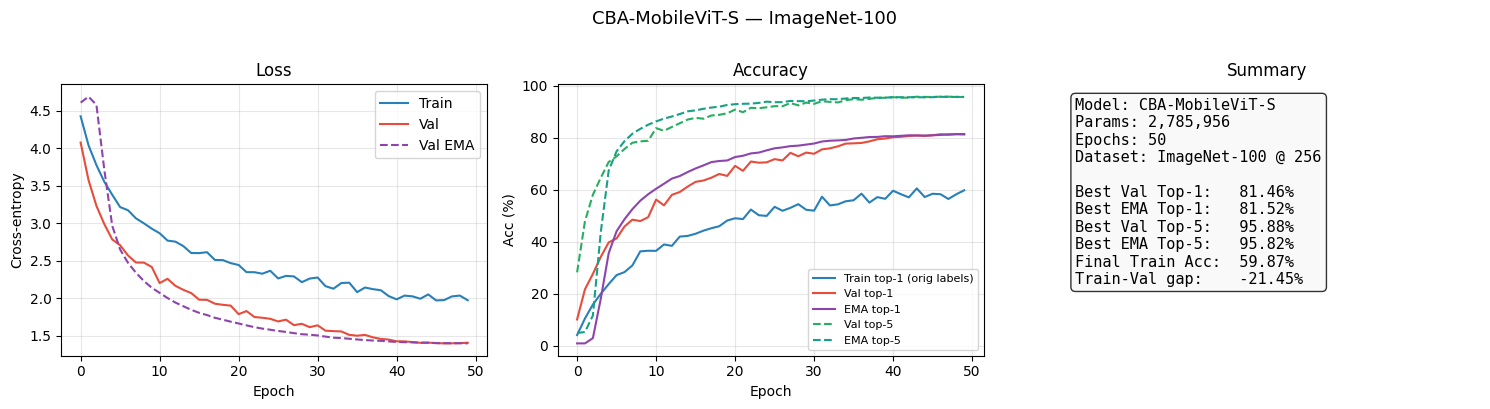

Saved /content/drive/MyDrive/colab/cba_mobilevit_s_lite_in100_results.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'],   label='Train',   color='#2980b9', lw=1.5)
axes[0].plot(history['val_loss'],     label='Val',     color='#e74c3c', lw=1.5)
axes[0].plot(history['ema_val_loss'], label='Val EMA', color='#8e44ad', lw=1.5, ls='--')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy — train (vs original labels), val (live + EMA), top-5
axes[1].plot(history['train_acc1'],   label='Train top-1 (orig labels)', color='#2980b9', lw=1.5)
axes[1].plot(history['val_acc1'],     label='Val top-1',                 color='#e74c3c', lw=1.5)
axes[1].plot(history['ema_val_acc1'], label='EMA top-1',                 color='#8e44ad', lw=1.5)
axes[1].plot(history['val_acc5'],     label='Val top-5',                 color='#27ae60', lw=1.5, ls='--')
axes[1].plot(history['ema_val_acc5'], label='EMA top-5',                 color='#16a085', lw=1.5, ls='--')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Acc (%)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Summary text
ax = axes[2]
ax.axis('off')
summary = [
    f'Model: CBA-MobileViT-S',
    f'Params: {sum(p.numel() for p in model.parameters()):,}',
    f'Epochs: {CFG["epochs"]}',
    f'Dataset: ImageNet-100 @ {CFG["img_size"]}',
    f'',
    f'Best Val Top-1:   {max(history["val_acc1"]):.2f}%',
    f'Best EMA Top-1:   {max(history["ema_val_acc1"]):.2f}%',
    f'Best Val Top-5:   {max(history["val_acc5"]):.2f}%',
    f'Best EMA Top-5:   {max(history["ema_val_acc5"]):.2f}%',
    f'Final Train Acc:  {history["train_acc1"][-1]:.2f}%',
    f'Train-Val gap:    {history["train_acc1"][-1] - history["val_acc1"][-1]:+.2f}%',
]
ax.text(0.05, 0.95, '\n'.join(summary), transform=ax.transAxes,
        va='top', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f8f8f8', alpha=0.8))
ax.set_title('Summary')

plt.suptitle('CBA-MobileViT-S — ImageNet-100', fontsize=13, y=1.01)
plt.tight_layout()
out_fig = Path(CFG['save_dir']) / f"{CFG['run_name']}_results.png"
plt.savefig(out_fig, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved {out_fig}')